In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("House Price.csv")

print(df.head())

  POSTED_BY  UNDER_CONSTRUCTION  RERA  BHK_NO. BHK_OR_RK    SQUARE_FT  \
0     Owner                   0     0        2       BHK  1300.236407   
1    Dealer                   0     0        2       BHK  1275.000000   
2     Owner                   0     0        2       BHK   933.159722   
3     Owner                   0     1        2       BHK   929.921143   
4    Dealer                   1     0        2       BHK   999.009247   

   READY_TO_MOVE  RESALE                      ADDRESS  LONGITUDE   LATITUDE  \
0              1       1        Ksfc Layout,Bangalore  12.969910  77.597960   
1              1       1    Vishweshwara Nagar,Mysore  12.274538  76.644605   
2              1       1             Jigani,Bangalore  12.778033  77.632191   
3              1       1  Sector-1 Vaishali,Ghaziabad  28.642300  77.344500   
4              0       1             New Town,Kolkata  22.592200  88.484911   

   TARGET(PRICE_IN_LACS)  
0                   55.0  
1                   51.0  
2    

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  str    
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  str    
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  str    
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 3.5 MB
None


In [5]:
print(df.describe().T)

                         count          mean           std         min  \
UNDER_CONSTRUCTION     29451.0      0.179756  3.839908e-01    0.000000   
RERA                   29451.0      0.317918  4.656753e-01    0.000000   
BHK_NO.                29451.0      2.392279  8.790913e-01    1.000000   
SQUARE_FT              29451.0  19802.170190  1.901335e+06    3.000000   
READY_TO_MOVE          29451.0      0.820244  3.839908e-01    0.000000   
RESALE                 29451.0      0.929578  2.558613e-01    0.000000   
LONGITUDE              29451.0     21.300255  6.205306e+00  -37.713008   
LATITUDE               29451.0     76.837695  1.055775e+01 -121.761248   
TARGET(PRICE_IN_LACS)  29451.0    142.898746  6.568807e+02    0.250000   

                              25%          50%          75%           max  
UNDER_CONSTRUCTION       0.000000     0.000000     0.000000  1.000000e+00  
RERA                     0.000000     0.000000     1.000000  1.000000e+00  
BHK_NO.                  2.0000

In [6]:
print(df.isnull().sum())

POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64


In [8]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0
0


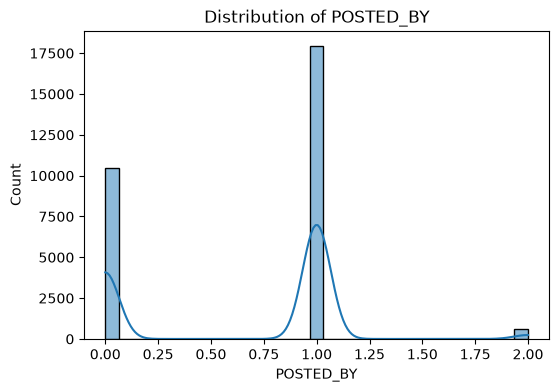

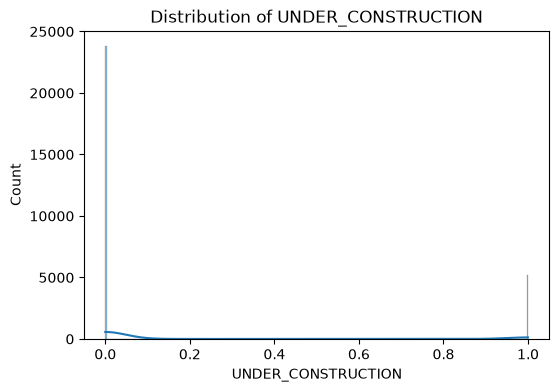

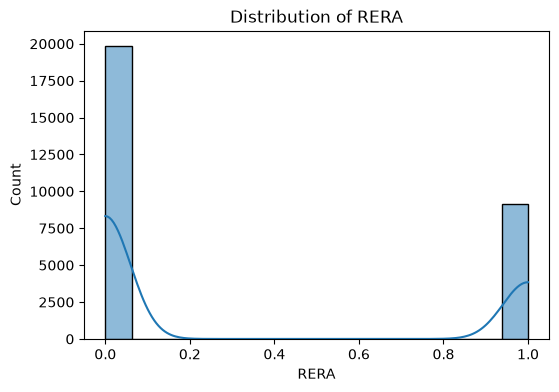

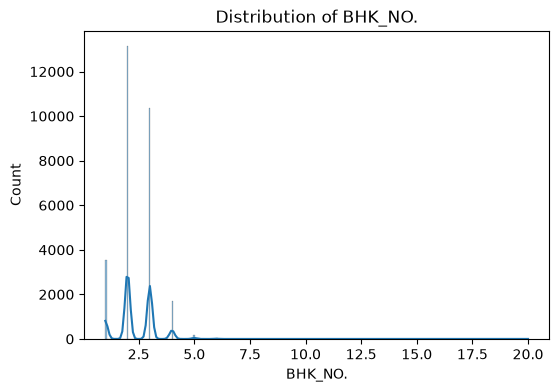

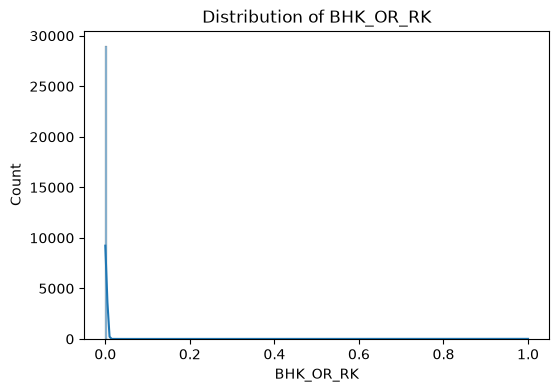

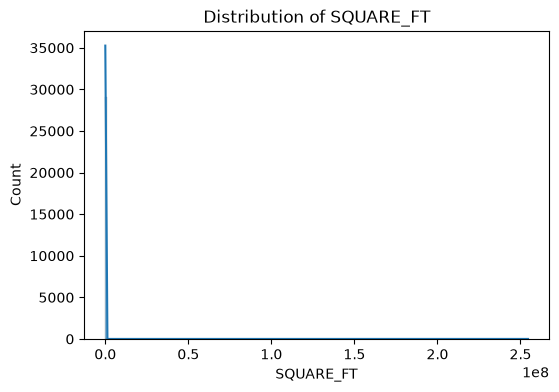

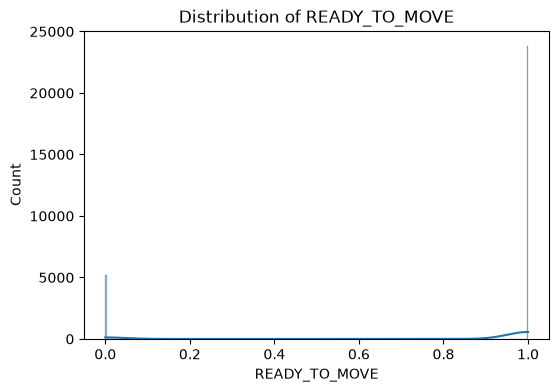

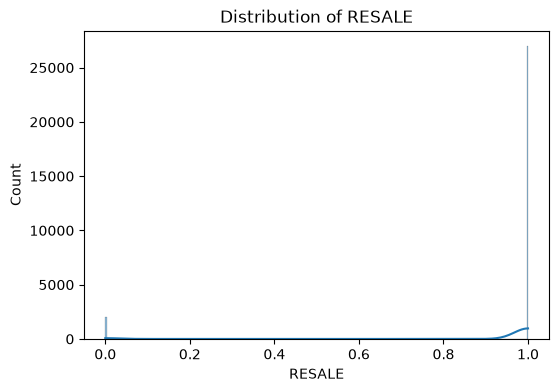

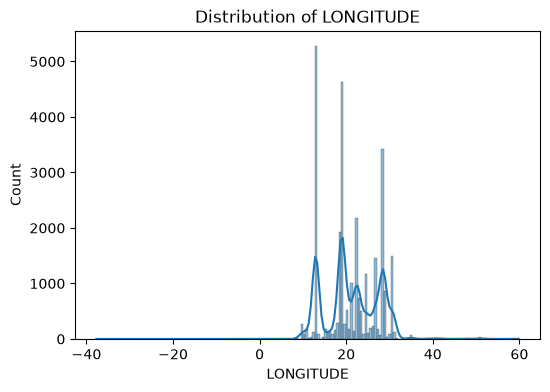

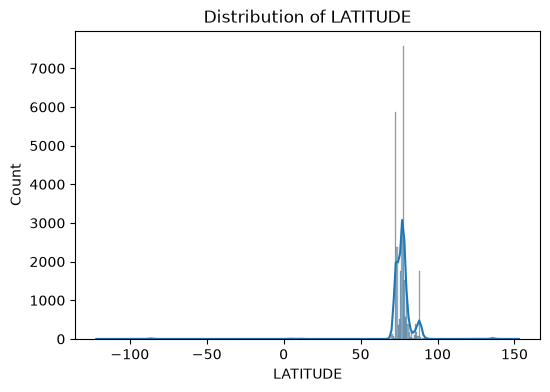

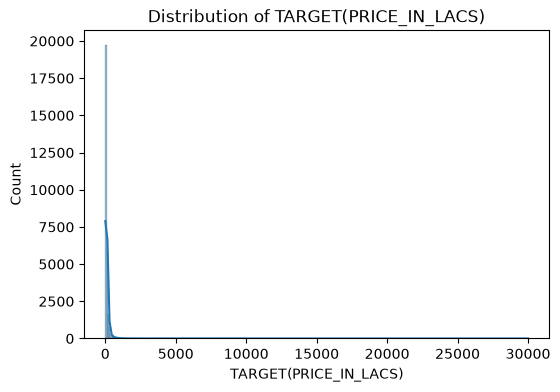

In [9]:
df['POSTED_BY'] = df['POSTED_BY'].map({'Owner': 0, 'Dealer': 1, 'Builder': 2})

df['BHK_OR_RK'] = df['BHK_OR_RK'].map({'BHK': 0, 'RK': 1})


if 'ADDRESS' in df.columns:
    df.drop(['ADDRESS'], axis=1, inplace=True)
    
num_cols = ['POSTED_BY','UNDER_CONSTRUCTION','RERA','BHK_NO.','BHK_OR_RK','SQUARE_FT',
            'READY_TO_MOVE','RESALE','LONGITUDE','LATITUDE',
            'TARGET(PRICE_IN_LACS)']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


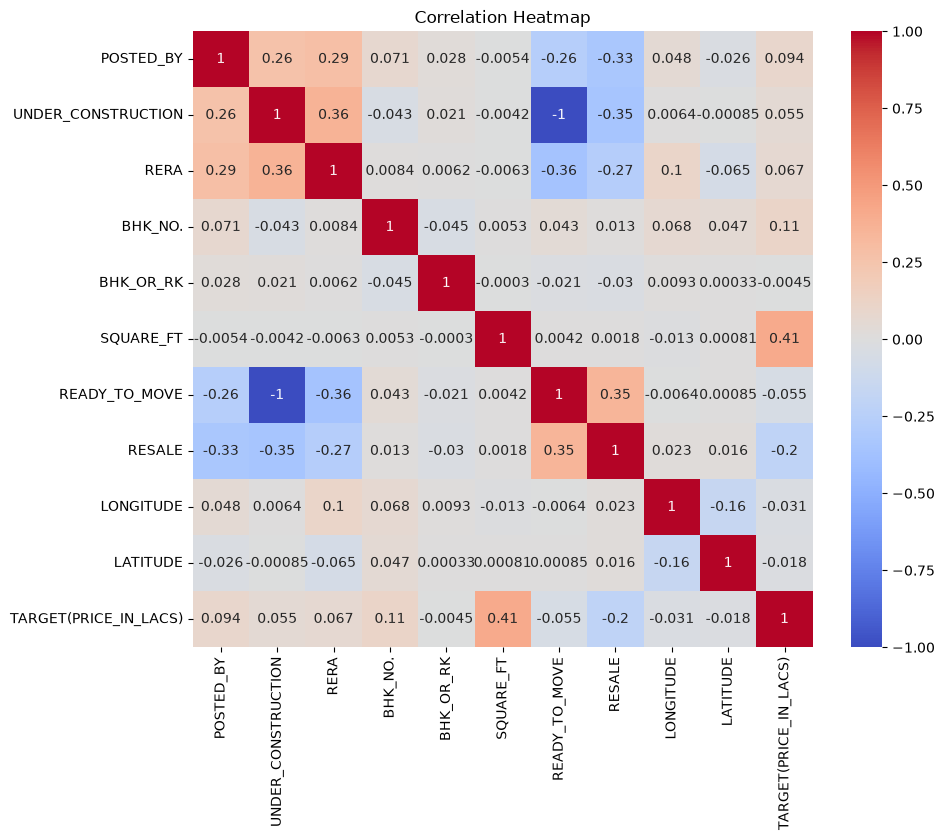

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:

""" print (df[num_cols].skew())
# Columns to skip from skewness check
skip_cols = ["LONGITUDE", "LATITUDE", "UNDER_CONSTRUCTION", "READY_TO_MOVE", "RESALE", "BHK_OR_RK"]

# Compute skewness
skew_vals = df[num_cols].skew().abs()

# Filter skewed columns while skipping unwanted ones
skewed_cols = [col for col in skew_vals.index if skew_vals[col] > 1 and col not in skip_cols]

df[skewed_cols] = np.log1p(df[skewed_cols])  
print("Skewed columns:", skewed_cols)
print(df[skewed_cols].skew()) """

In [11]:
print(df[num_cols].skew())

POSTED_BY                 -0.208811
UNDER_CONSTRUCTION         1.675076
RERA                       0.792238
BHK_NO.                    2.411951
BHK_OR_RK                 34.749708
SQUARE_FT                115.812901
READY_TO_MOVE             -1.675076
RESALE                    -3.381700
LONGITUDE                  0.185040
LATITUDE                 -10.322082
TARGET(PRICE_IN_LACS)     17.971976
dtype: float64


In [12]:
print(df.isna().sum())

POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64


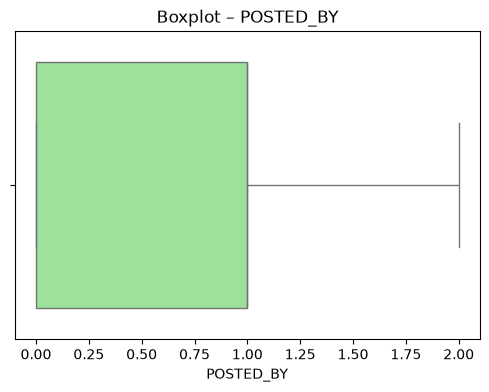

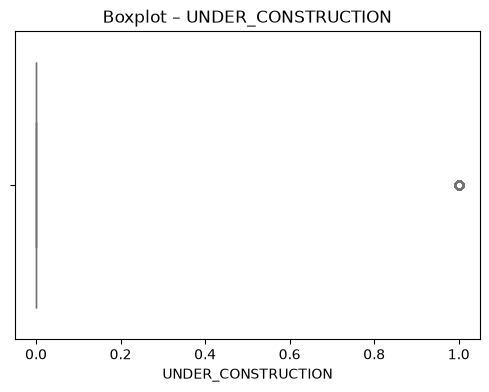

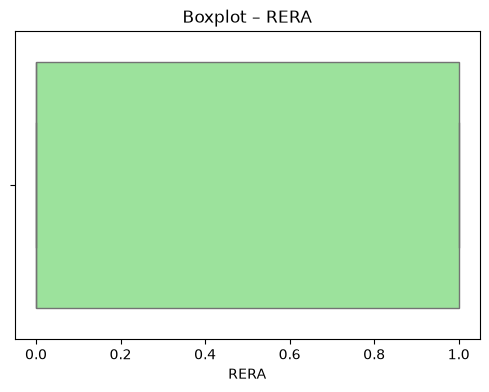

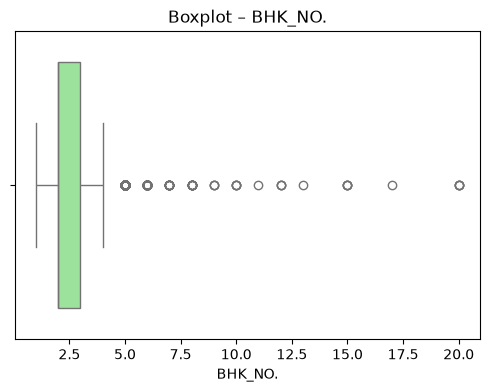

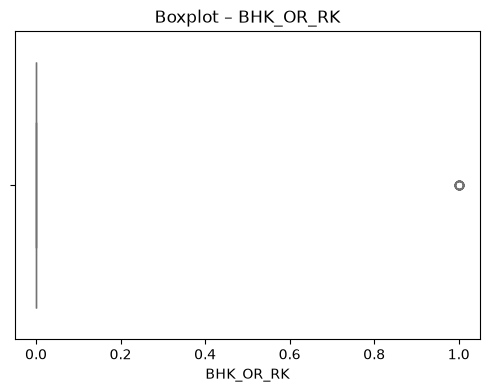

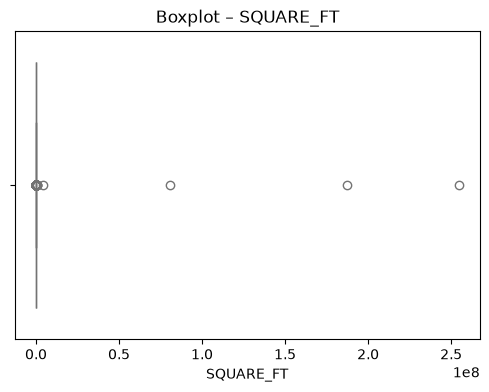

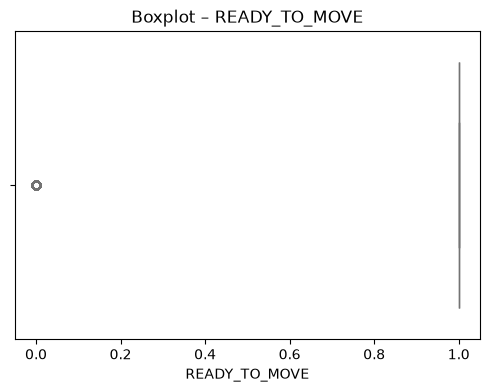

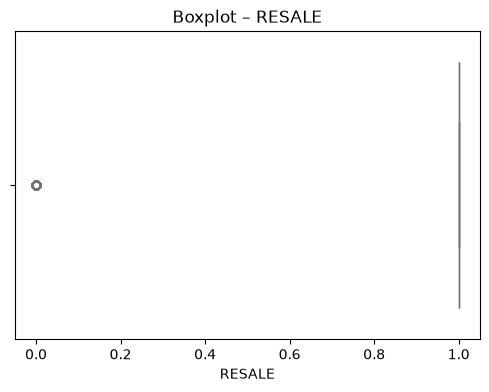

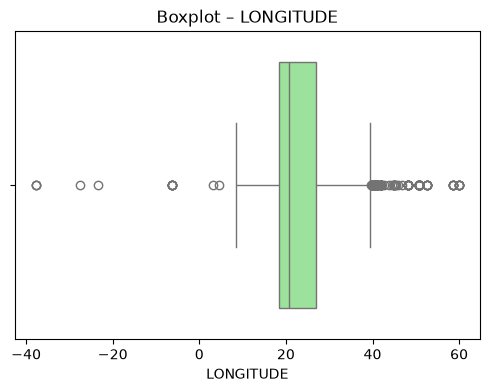

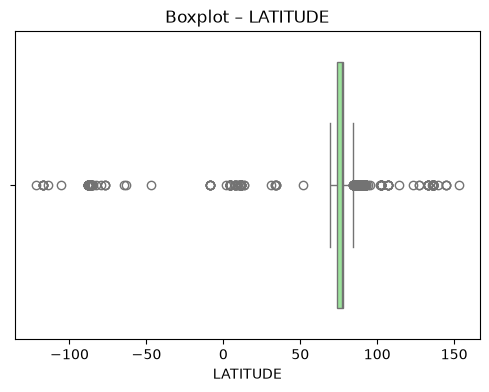

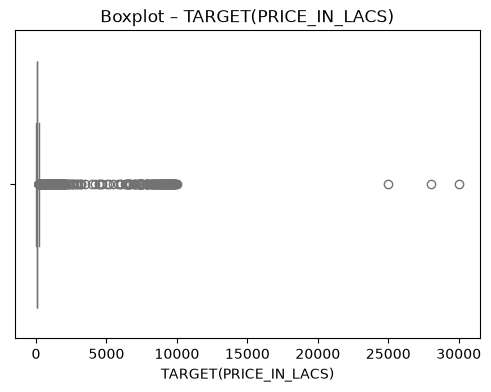

In [13]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f"Boxplot – {col}")
    plt.xlabel(col)
    plt.show()


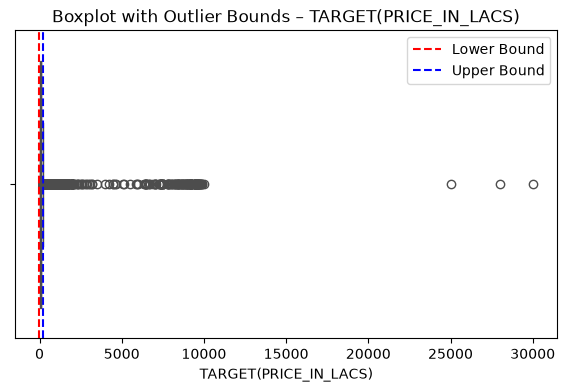

In [14]:
col = "TARGET(PRICE_IN_LACS)"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

plt.figure(figsize=(7,4))
sns.boxplot(x=df[col], color="orange")

plt.axvline(lower, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper, color='blue', linestyle='--', label='Upper Bound')

plt.title(f"Boxplot with Outlier Bounds – {col}")
plt.legend()
plt.show()


In [ ]:
"""
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]
for col in num_cols:
    df = remove_outliers(df, col)
"""

In [15]:
target = "TARGET(PRICE_IN_LACS)"
X = df.drop(columns=[target])
y = df[target]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
Scaler=StandardScaler()
X_Train_Scaled = Scaled=Scaler.fit_transform(X_train)
X_Test_Scaled =  Scaled=Scaler.transform(X_test)


In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42)
}

results = []

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2


for name, model in models.items():
    # Handle NaN values by filling with mean
    X_train_filled = np.nan_to_num(X_Train_Scaled, nan=np.nanmean(X_Train_Scaled))
    X_test_filled = np.nan_to_num(X_Test_Scaled, nan=np.nanmean(X_Train_Scaled))
    
    model.fit(X_train_filled, y_train)
    
    
    y_train_pred = model.predict(X_Train_Scaled)
    y_test_pred = model.predict(X_Test_Scaled)
    
    mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred)
    mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred)
    
    results.append([name, rmse_tr, rmse_te, r2_tr, r2_te,
                    "Y" if (r2_tr - r2_te) > 0.05 else "N"])

results_df = pd.DataFrame(results, columns=[
    "Model","Train RMSE","Test RMSE","Train R2","Test R2","Overfitting"
])

results_df_sorted = results_df.sort_values(
    by=["Test R2", "Test RMSE"],
    ascending=[False, False]
)

print(results_df_sorted)


Learning rate set to 0.067305
0:	learn: 596.8742185	total: 144ms	remaining: 2m 24s
1:	learn: 569.4083788	total: 148ms	remaining: 1m 13s
2:	learn: 544.7894670	total: 151ms	remaining: 50.1s
3:	learn: 520.4143909	total: 153ms	remaining: 38.2s
4:	learn: 496.4812730	total: 156ms	remaining: 31s
5:	learn: 475.0965279	total: 158ms	remaining: 26.1s
6:	learn: 455.7255637	total: 160ms	remaining: 22.7s
7:	learn: 436.4811195	total: 162ms	remaining: 20.1s
8:	learn: 418.1308856	total: 164ms	remaining: 18.1s
9:	learn: 401.4714324	total: 166ms	remaining: 16.4s
10:	learn: 385.9137202	total: 168ms	remaining: 15.1s
11:	learn: 371.1521180	total: 170ms	remaining: 14s
12:	learn: 357.1690742	total: 172ms	remaining: 13s
13:	learn: 344.3175649	total: 174ms	remaining: 12.2s
14:	learn: 333.0023564	total: 176ms	remaining: 11.5s
15:	learn: 321.3259838	total: 178ms	remaining: 10.9s
16:	learn: 310.5485538	total: 180ms	remaining: 10.4s
17:	learn: 300.4864352	total: 182ms	remaining: 9.9s
18:	learn: 290.9947501	total: 1

In [19]:
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)


param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [5, 10, 20, 30],
    'min_samples_leaf': [2, 5, 10, 15],
    'max_features': ['sqrt', 'log2', None]
}

grid_dt = GridSearchCV(
    
    dt,
    param_grid_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_Train_Scaled, y_train)
best_dt = grid_dt.best_estimator_

y_train_pred_best_dt = best_dt.predict(X_Train_Scaled)
y_test_pred_best_dt = best_dt.predict(X_Test_Scaled)

mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred_best_dt)
mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred_best_dt)

results.append(["Decision Tree Tuned", rmse_tr, rmse_te, r2_tr, r2_te,"Y" if (r2_tr - r2_te) > 0.05 else "N"])

results_df = pd.DataFrame(results, columns=[
    "Model","Train RMSE","Test RMSE","Train R2","Test R2","Overfitting"
])

Fitting 5 folds for each of 192 candidates, totalling 960 fits


In [20]:
# Random Forest tuning
rf = RandomForestRegressor(random_state=42)

param_grid_rf  = {
    "n_estimators": [500, 700],
    "max_depth": [20, 30, None],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["log2"]
}

grid_rf = GridSearchCV(
    rf, param_grid_rf, cv=2, scoring='r2', n_jobs=-1, verbose=1
)
grid_rf.fit(X_Train_Scaled, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
y_train_pred_best_rf = best_rf.predict(X_Train_Scaled)
y_test_pred_best_rf = best_rf.predict(X_Test_Scaled)
    
mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred_best_rf)
mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred_best_rf)

results.append(["Random Forest Tuned1", rmse_tr, rmse_te, r2_tr, r2_te,
                "Y" if (r2_tr - r2_te) > 0.05 else "N"])
results_df = pd.DataFrame(results, columns=[
    "Model","Train RMSE","Test RMSE","Train R2","Test R2","Overfitting"
])

Fitting 2 folds for each of 36 candidates, totalling 72 fits
Best RF params: {'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best RF CV score: 0.8647914351970081


In [21]:

results_df_sorted = results_df.sort_values(
    by=["Test R2", "Test RMSE"],
    ascending=[False, False]
)

print(results_df_sorted)

                   Model  Train RMSE   Test RMSE  Train R2   Test R2  \
5      Gradient Boosting  100.997681  168.631468  0.973931  0.948067   
9    Decision Tree Tuned   79.601085  182.593998  0.983807  0.939111   
2          Random Forest   83.001244  184.545356  0.982394  0.937803   
1          Decision Tree    8.314232  190.544934  0.999823  0.933693   
10  Random Forest Tuned1   88.077924  263.877483  0.980174  0.872835   
7               CatBoost   65.284330  350.774351  0.989108  0.775292   
8               LightGBM  189.642363  378.059284  0.908088  0.738975   
6                XGBoost   48.595116  434.065895  0.993965  0.655908   
4                    KNN  341.420166  494.280080  0.702095  0.553821   
0      Linear Regression  563.288411  608.967050  0.189112  0.322748   
3                    SVR  624.052703  739.361887  0.004728  0.001664   

   Overfitting  
5            N  
9            N  
2            N  
1            Y  
10           Y  
7            Y  
8            Y  

In [22]:
#KNN tuning
knn = KNeighborsRegressor()

param_grid_knn = {
    'n_neighbors': [5, 7, 9, 11, 15, 21, 25, 31],
    'weights': ['uniform'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

grid_knn = GridSearchCV(
    knn, param_grid_knn, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_knn.fit(X_Train_Scaled, y_train)
best_knn = grid_knn.best_estimator_
y_train_pred_best_knn = best_knn.predict(X_Train_Scaled)
y_test_pred_best_knn = best_knn.predict(X_Test_Scaled)

mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred_best_knn)
mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred_best_knn)

results.append(["KNN Tuned", rmse_tr, rmse_te, r2_tr, r2_te,
                "Y" if (r2_tr - r2_te) > 0.05 else "N"])
results_df = pd.DataFrame(results, columns=[
    "Model","Train RMSE","Test RMSE","Train R2","Test R2","Overfitting"
])

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [23]:
gd = GradientBoostingRegressor(random_state=42)
param_grid_gd = {
    "n_estimators": [100, 200, 300],    
    "learning_rate": [0.1, 0.05, 0.01]
}
grid_gd = GridSearchCV(
    gd, param_grid_gd, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_gd.fit(X_Train_Scaled, y_train)
best_gd = grid_gd.best_estimator_
y_train_pred_best_gd = best_gd.predict(X_Train_Scaled)
y_test_pred_best_gd = best_gd.predict(X_Test_Scaled)

mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred_best_gd)
mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred_best_gd)

results.append(["Gradient Boosting Tuned", rmse_tr, rmse_te, r2_tr, r2_te,
                "Y" if (r2_tr - r2_te) > 0.05 else "N"])
results_df = pd.DataFrame(results, columns=[
    "Model","Train RMSE","Test RMSE","Train R2","Test R2","Overfitting"
])

Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [24]:

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


xgb.fit(X_Train_Scaled, y_train)
y_train_pred_best_rf = xgb.predict(X_Train_Scaled)
y_test_pred_best_rf = xgb.predict(X_Test_Scaled)
    
mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred_best_rf)
mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred_best_rf)

results.append(["XGBoost 1", rmse_tr, rmse_te, r2_tr, r2_te,
                "Y" if (r2_tr - r2_te) > 0.05 else "N"])
results_df = pd.DataFrame(results, columns=[
    "Model","Train RMSE","Test RMSE","Train R2","Test R2","Overfitting"
])


In [25]:
xgb = XGBRegressor(random_state=42)
param_grid_xgb = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01],
    'max_depth': [6],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'random_state': [42],
    'reg_alpha': [0.1, 0.5, 1, 5],
    'reg_lambda': [1, 5, 10, 20]
}


grid_xgb = GridSearchCV(
    xgb, param_grid_xgb, cv=3, scoring='r2', n_jobs=-1, verbose=1
)

grid_xgb.fit(X_Train_Scaled, y_train)
y_train_pred_best_rf = grid_xgb.predict(X_Train_Scaled)
y_test_pred_best_rf = grid_xgb.predict(X_Test_Scaled)

mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred_best_rf)
mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred_best_rf)

results.append(["XGBoost Tuned1", rmse_tr, rmse_te, r2_tr, r2_te,
                "Y" if (r2_tr - r2_te) > 0.05 else "N"])
results_df = pd.DataFrame(results, columns=[
    "Model","Train RMSE","Test RMSE","Train R2","Test R2","Overfitting"
])


Fitting 3 folds for each of 288 candidates, totalling 864 fits


In [26]:

cat = CatBoostRegressor(
    loss_function='RMSE',
    random_state=42,
    verbose=0
)



param_grid = {
    'iterations': [1000, 1500],
    'learning_rate': [0.03, 0.05],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [3, 5]
}

grid_search = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    scoring='r2',
    cv=2,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_Train_Scaled, y_train)

y_train_pred_best_cboost = grid_search.predict(X_Train_Scaled)
y_test_pred_best_cboost = grid_search.predict(X_Test_Scaled)

mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred_best_cboost)
mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred_best_cboost)

results.append(["CatBoost Tuned", rmse_tr, rmse_te, r2_tr, r2_te,
                "Y" if (r2_tr - r2_te) > 0.05 else "N"])
results_df = pd.DataFrame(results, columns=[
    "Model","Train RMSE","Test RMSE","Train R2","Test R2","Overfitting"
])


Fitting 2 folds for each of 24 candidates, totalling 48 fits


In [27]:
from sklearn.model_selection import RandomizedSearchCV


lgbm = LGBMRegressor(
    objective='regression',
    random_state=42,
    verbosity=-1
)

param_grid_lgbm = {
    'n_estimators': [500, 1000, 1500, 2000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'num_leaves': [15, 31, 50, 70],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5]
}

random_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid_lgbm,
    n_iter=15,          
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


random_lgbm.fit(X_Train_Scaled, y_train)

y_train_pred_best_lgbm = random_lgbm.predict(X_Train_Scaled)
y_test_pred_best_lgbm = random_lgbm.predict(X_Test_Scaled)

mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred_best_lgbm)
mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred_best_lgbm)

results.append(["LightGBM Tuned", rmse_tr, rmse_te, r2_tr, r2_te,
                "Y" if (r2_tr - r2_te) > 0.05 else "N"])
results_df = pd.DataFrame(results, columns=[
    "Model","Train RMSE","Test RMSE","Train R2","Test R2","Overfitting"
])



Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [28]:
print("Model comparison Table:")

results_df_sorted = results_df.sort_values(
    by=["Test R2", "Test RMSE"],
    ascending=[False, False]
)

print(results_df_sorted)

Model comparison Table:
                      Model  Train RMSE   Test RMSE  Train R2   Test R2  \
12  Gradient Boosting Tuned   76.625396  165.179192  0.984995  0.950172   
5         Gradient Boosting  100.997681  168.631468  0.973931  0.948067   
9       Decision Tree Tuned   79.601085  182.593998  0.983807  0.939111   
2             Random Forest   83.001244  184.545356  0.982394  0.937803   
1             Decision Tree    8.314232  190.544934  0.999823  0.933693   
10     Random Forest Tuned1   88.077924  263.877483  0.980174  0.872835   
13                XGBoost 1   54.186323  348.606033  0.992496  0.778062   
15           CatBoost Tuned   79.154770  350.125882  0.983988  0.776122   
7                  CatBoost   65.284330  350.774351  0.989108  0.775292   
16           LightGBM Tuned  132.988821  356.478258  0.954801  0.767925   
14           XGBoost Tuned1  193.999955  358.186664  0.903816  0.765695   
8                  LightGBM  189.642363  378.059284  0.908088  0.738975   
6

In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
best_gd = grid_gd.best_estimator_
y_train_pred_best_gd = best_gd.predict(X_Train_Scaled)
y_test_pred_best_gd = best_gd.predict(X_Test_Scaled)

#mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train, y_train_pred_best_gd)
#mae_te, mse_te, rmse_te, r2_te = metrics(y_test, y_test_pred_best_gd)

print("Train R2:", r2_score(y_train, y_train_pred_best_gd ))
print("Test R2:", r2_score(y_test, y_test_pred_best_gd))
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred_best_gd))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred_best_gd))

Train R2: 0.9849946926126495
Test R2: 0.9501719974353313
Test RMSE: 165.17919181568226
Test MAE: 40.39590950306167


In [31]:

import joblib
joblib.dump(best_gd,"GradientBoostingTuned.pkl")
joblib.dump(Scaler,"feature_Scaler.pkl")

['feature_Scaler.pkl']

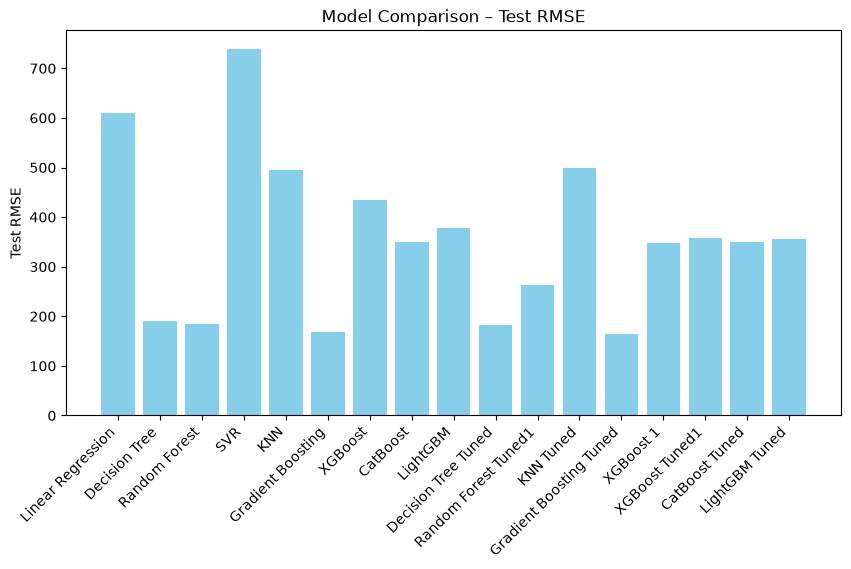

In [32]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Test RMSE"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Test RMSE")
plt.title("Model Comparison – Test RMSE")
plt.show()


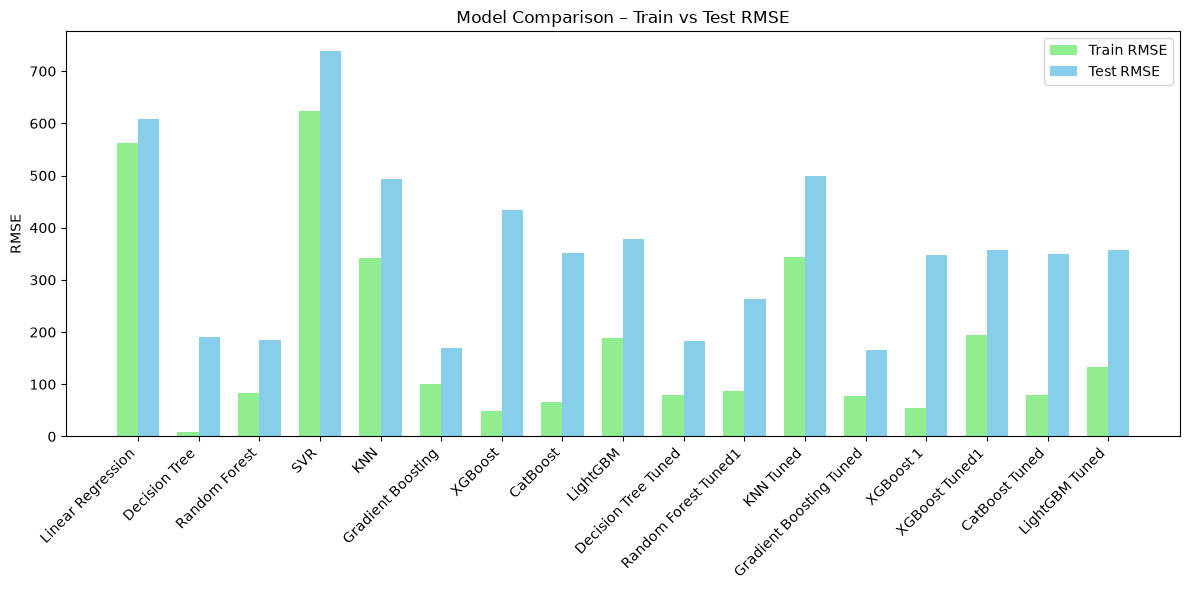

In [33]:
models = results_df["Model"]
train_rmse = results_df["Train RMSE"]
test_rmse = results_df["Test RMSE"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, train_rmse, width, label='Train RMSE', color='lightgreen')
plt.bar(x + width/2, test_rmse, width, label='Test RMSE', color='skyblue')

plt.xticks(x, models, rotation=45, ha='right')
plt.ylabel("RMSE")
plt.title("Model Comparison – Train vs Test RMSE")
plt.legend()
plt.tight_layout()
plt.show()


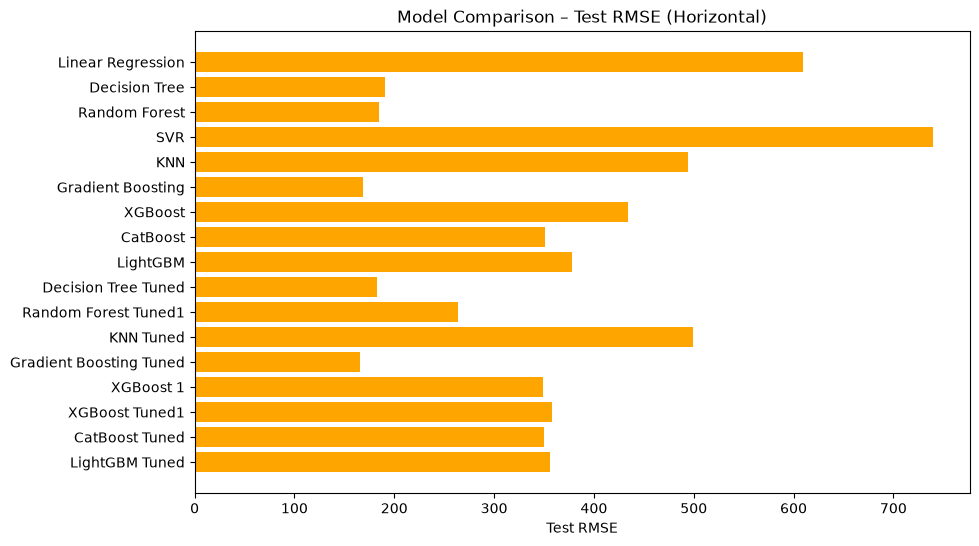

In [34]:
plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["Test RMSE"], color='orange')
plt.xlabel("Test RMSE")
plt.title("Model Comparison – Test RMSE (Horizontal)")
plt.gca().invert_yaxis()   # highest model at top
plt.show()


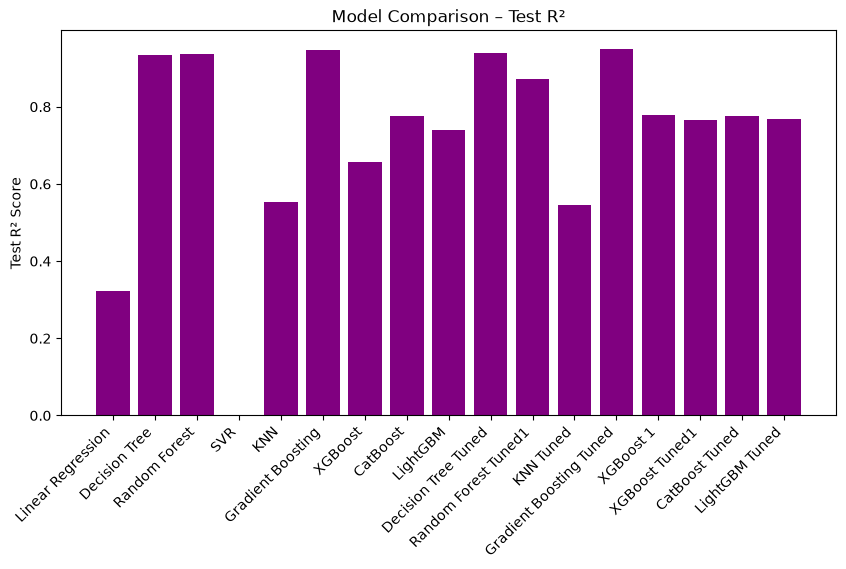

In [35]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Test R2"], color='purple')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Test R² Score")
plt.title("Model Comparison – Test R²")
plt.show()


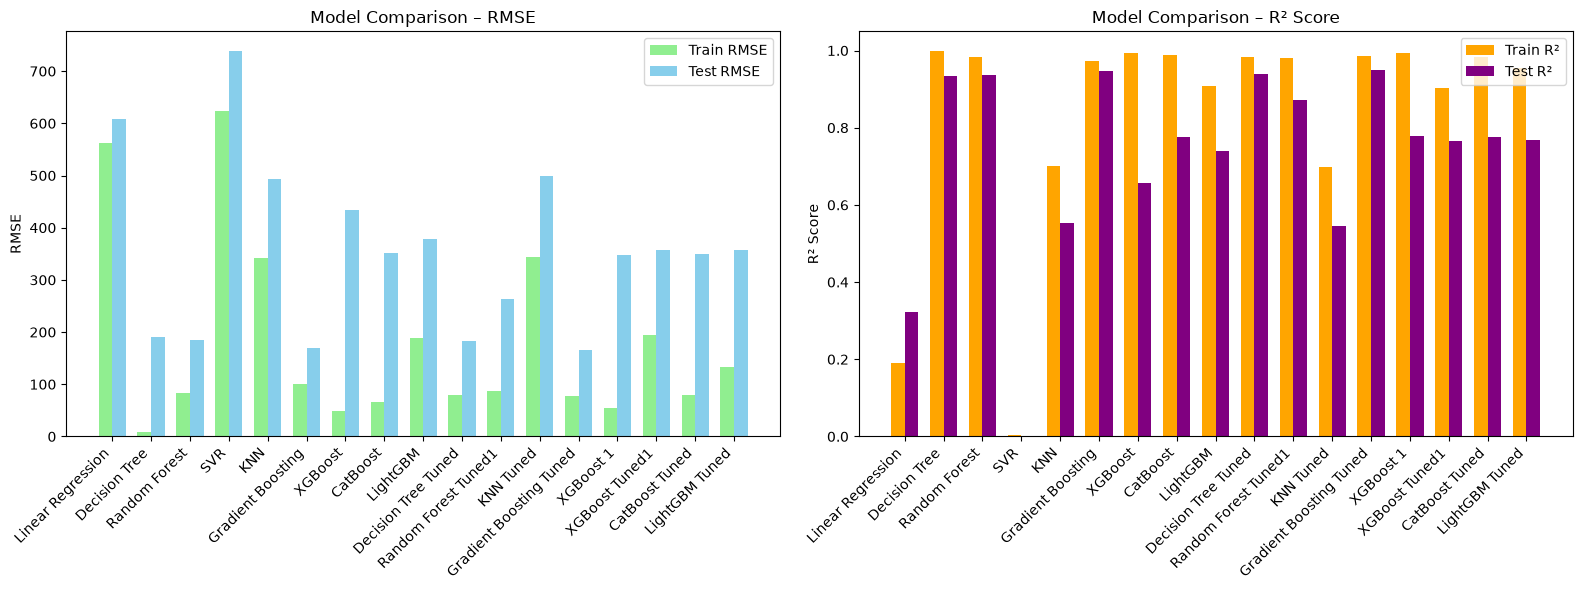

In [36]:
models = results_df["Model"]
train_rmse = results_df["Train RMSE"]
test_rmse = results_df["Test RMSE"]
train_r2 = results_df["Train R2"]
test_r2 = results_df["Test R2"]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# ---------------- RMSE subplot ----------------
axes[0].bar(x - width/2, train_rmse, width, label='Train RMSE', color='lightgreen')
axes[0].bar(x + width/2, test_rmse, width, label='Test RMSE', color='skyblue')

axes[0].set_title("Model Comparison – RMSE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel("RMSE")
axes[0].legend()

# ---------------- R² subplot ----------------
axes[1].bar(x - width/2, train_r2, width, label='Train R²', color='orange')
axes[1].bar(x + width/2, test_r2, width, label='Test R²', color='purple')

axes[1].set_title("Model Comparison – R² Score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylabel("R² Score")
axes[1].legend()

plt.tight_layout()
plt.show()
